# Лабораторная работа 1
## Датасет: Глобальные продажи BMW (2018-2025)
## Шаг 1: Подготовка окружения в Google Colab

In [ ]:
# Импорт необходимых библиотек для анализа данных и визуализации
# numpy - работа с числовыми массивами
# pandas - работа с табличными данными
# matplotlib и seaborn - построение графиков
# scipy - статистические функции


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Отключаем предупреждения, чтобы не загромождать вывод
warnings.filterwarnings('ignore')

# Настройка стиля графиков для лучшей читаемости
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Разрешаем отображение графиков
%matplotlib inline

# Настраиваем pandas для полного отображения данных
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Загрузка данных датасэта из CSV-файла
df = pd.read_csv('bmw_global_sales_2018_2025.csv')

# Выводим базовую информацию о загруженных данных
print("Данные успешно загружены!")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

FileNotFoundError: [Errno 2] No such file or directory: 'bmw_global_sales_2018_2025.csv'

## Шаг 2:  Основные характеристики датасета
Блок выполняет первичную разведку данных. Метод head() показывает пример записей, dtypes отображает типы столбцов, isnull().sum() проверяет наличие пропусков, а describe() даёт сводную статистику (среднее, минимум, максимум и т.д.) для числовых переменных. Здесь мы исследуем категориальные переменные. value_counts() показывает частоту каждой категории, что важно для понимания баланса данных и планирования дальнейшей визуализации.

In [ ]:
print("Первые 5 строк датасета:")
display(df.head())

print("\nИнформация о типах данных:")
print(df.dtypes)

print("\nПропущенные значения в каждом столбце:")
print(df.isnull().sum())

print("\nСтатистические характеристики числовых признаков:")
display(df.describe().T)

# Анализ уникальных значений категориальных признаков
# Помогает понять, какие категории представлены в данных

print("Уникальные значения признака Region:")
print(df['Region'].unique())

print("\nУникальные значения признака Model:")
print(df['Model'].unique())

print("\nРаспределение записей по регионам:")
print(df['Region'].value_counts())

print("\nРаспределение записей по моделям:")
print(df['Model'].value_counts())

Первые 5 строк датасета:


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.120,3.500,1.000
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.120,3.500,1.000
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.120,3.500,1.000
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.120,3.500,1.000
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.120,3.500,1.000



Информация о типах данных:
Year                  int64
Month                 int64
Region               object
Model                object
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object

Пропущенные значения в каждом столбце:
Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

Статистические характеристики числовых признаков:


,count,mean,std,min,25%,50%,75%,max
Year,3072.000,2021.500,2.292,2018.000,2019.750,2021.500,2023.250,2025.000
Month,3072.000,6.500,3.453,1.000,3.750,6.500,9.250,12.000
Units_Sold,3072.000,7980.288,3174.917,2379.000,5225.500,7985.500,10528.250,15914.000
Avg_Price_EUR,3072.000,63854.562,14655.891,40011.000,54500.250,63493.000,71489.500,93994.000
Revenue_EUR,3072.000,511399511.106,243118525.976,104531427.000,312550352.250,480868969.000,670914128.500,1433481712.000
BEV_Share,3072.000,0.108,0.058,-0.015,0.057,0.108,0.157,0.223
Premium_Share,3072.000,14.660,5.335,5.090,12.275,16.260,18.933,20.970
GDP_Growth,3072.000,3.058,1.018,0.100,2.370,3.060,3.853,5.820
Fuel_Price_Index,3072.000,1.176,0.118,0.920,1.080,1.180,1.270,1.410


Уникальные значения признака Region:
['Europe' 'China' 'USA' 'RestOfWorld']

Уникальные значения признака Model:
['3 Series' '5 Series' 'X3' 'X5' 'X7' 'i4' 'iX' 'MINI']

Распределение записей по регионам:
Region
Europe         768
China          768
USA            768
RestOfWorld    768
Name: count, dtype: int64

Распределение записей по моделям:
Model
3 Series    384
5 Series    384
X3          384
X5          384
X7          384
i4          384
iX          384
MINI        384
Name: count, dtype: int64


## Шаг 3: Визуальное исследование датасета
Блок выполняет первичную разведку данных. Метод head() показывает пример записей, dtypes отображает типы столбцов, isnull().sum() проверяет наличие пропусков, а describe() даёт сводную статистику (среднее, минимум, максимум и т.д.) для числовых переменных. Здесь мы исследуем категориальные переменные. value_counts() показывает частоту каждой категории, что важно для понимания баланса данных и планирования дальнейшей визуализации. Круговая диаграмма отображает процентное соотношение продаж по моделям. Параметр autopct автоматически добавляет проценты на сектора, что делает диаграмму информативной без дополнительных подписей. Boxplot (ящик с усами) показывает медиану, квартили и выбросы в распределении цен. Это полезно для сравнения ценовых диапазонов моделей и обнаружения аномальных значений. Тепловая карта визуализирует матрицу продаж, где цвет ячейки отражает объём продаж. Аннотации с числами и цветовая шкала помогают быстро идентифицировать сильные и слабые комбинации регион-модель. Точечная диаграмма с кодированием цвета по региону и размера по объёму продаж позволяет исследовать многомерные взаимосвязи. Помогает оценить, коррелирует ли рост доли электромобилей с увеличением выручки. Pairplot строит матрицу графиков: по диагонали — распределения отдельных переменных, вне диагонали — рассеяние пар переменных. Это мощный инструмент для первичного выявления корреляций и паттернов.


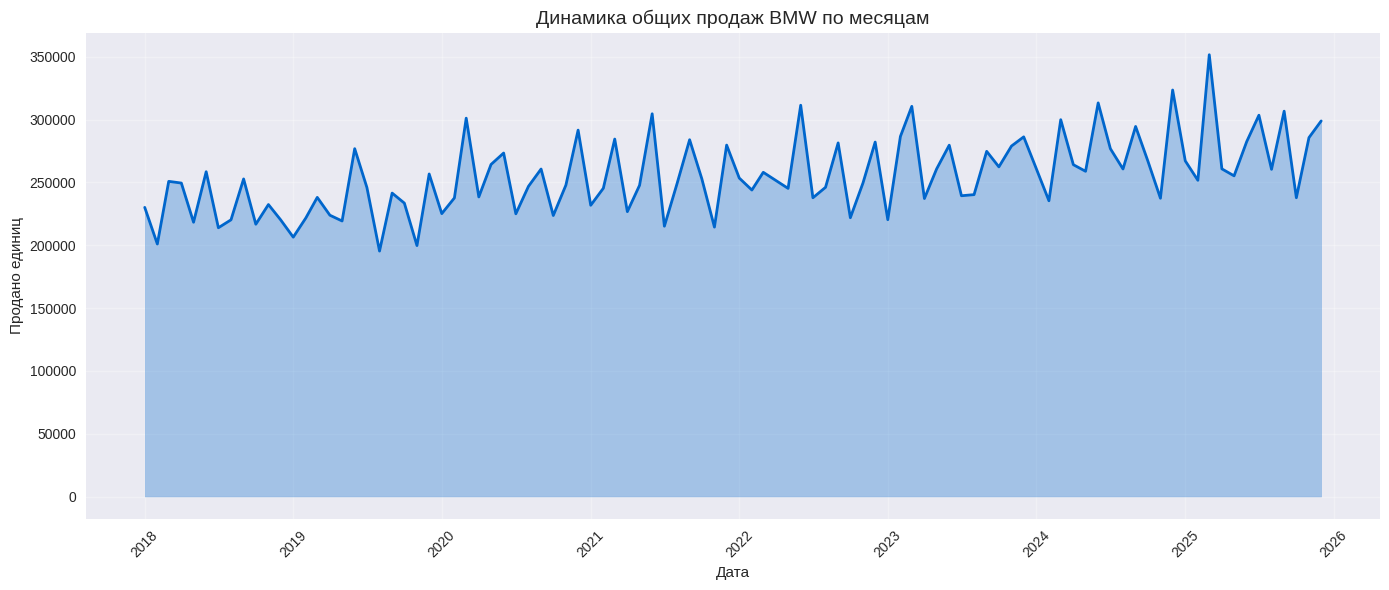

In [ ]:
# Создание временной метки для анализа динамики
# Объединяем год и месяц в один объект даты для построения временных рядов

df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Группируем данные по дате и суммируем проданные единицы
monthly_sales = df.groupby('Date')['Units_Sold'].sum().reset_index()

# Построение линейного графика динамики продаж
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date'], monthly_sales['Units_Sold'], linewidth=2, color='#0066CC')
plt.fill_between(monthly_sales['Date'], monthly_sales['Units_Sold'], alpha=0.3, color='#0066CC')
plt.title('Динамика общих продаж BMW по месяцам', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Продано единиц')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




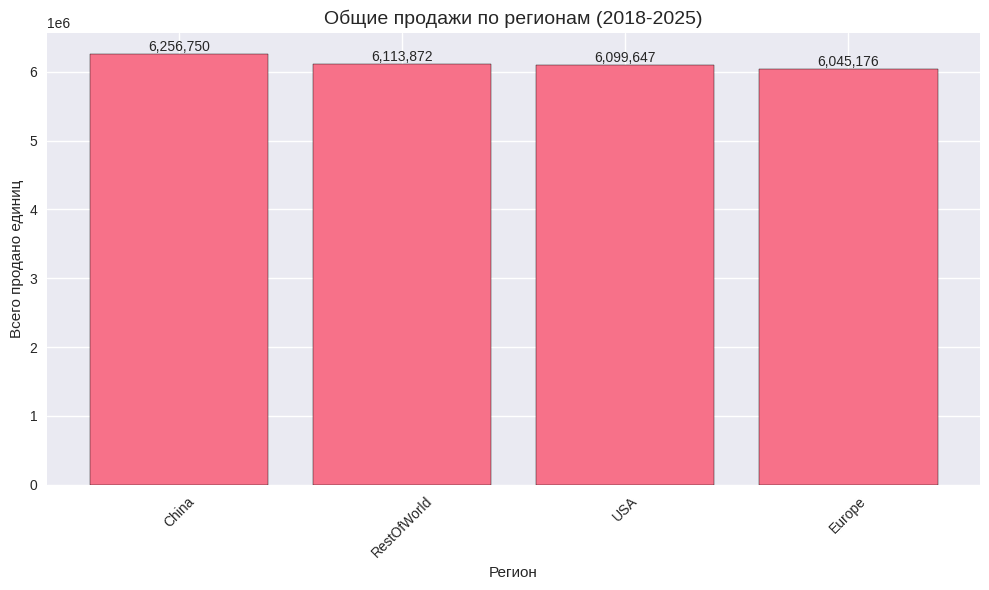

In [ ]:
# Столбчатая диаграмма: общие продажи по регионам
# Позволяет сравнить объёмы продаж между разными рынками

region_sales = df.groupby('Region')['Units_Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(region_sales.index, region_sales.values,
               edgecolor='black')
plt.title('Общие продажи по регионам (2018-2025)', fontsize=14)
plt.xlabel('Регион')
plt.ylabel('Всего продано единиц')
plt.xticks(rotation=45)

# Добавляем значения на столбцы для наглядности
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:,.0f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

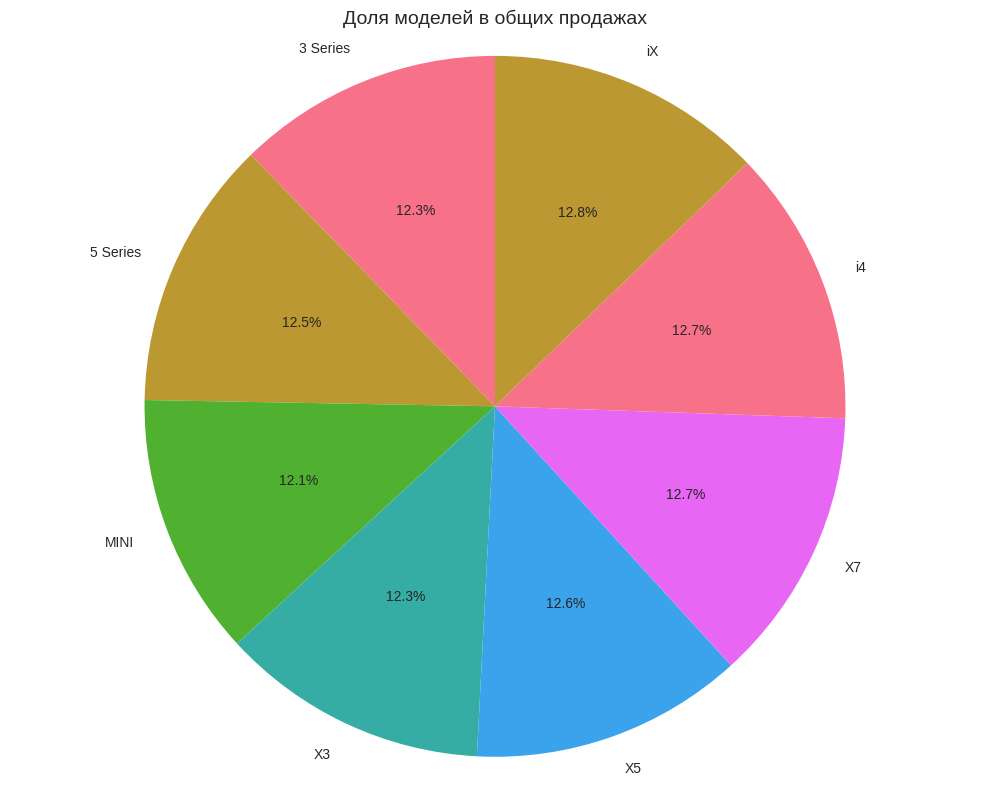

In [ ]:
# Круговая диаграмма: доля моделей в общих продажах
# Показывает структуру ассортимента по популярности

model_sales = df.groupby('Model')['Units_Sold'].sum()

plt.figure(figsize=(10, 8))
plt.pie(model_sales.values, labels=model_sales.index, autopct='%1.1f%%',
        startangle=90)
plt.title('Доля моделей в общих продажах', fontsize=14)
plt.axis('equal')  # Обеспечивает круглую форму диаграммы
plt.tight_layout()
plt.show()

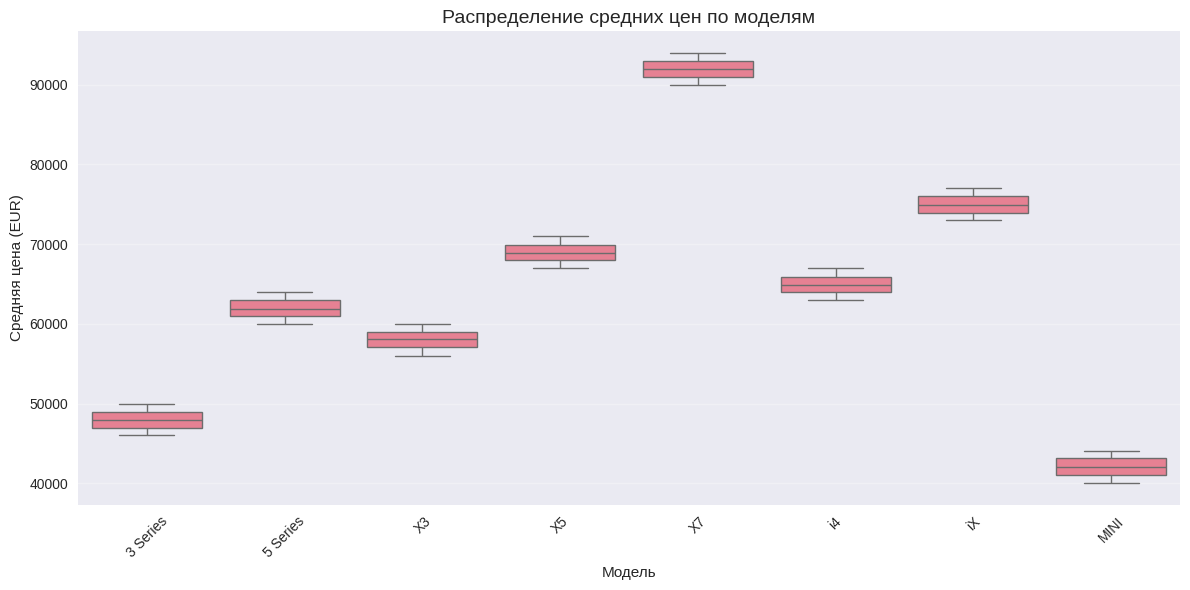

In [ ]:
# Boxplot: распределение цен по моделям
# Позволяет оценить разброс цен и выявить выбросы для каждой модели

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Model', y='Avg_Price_EUR')
plt.title('Распределение средних цен по моделям', fontsize=14)
plt.xlabel('Модель')
plt.ylabel('Средняя цена (EUR)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

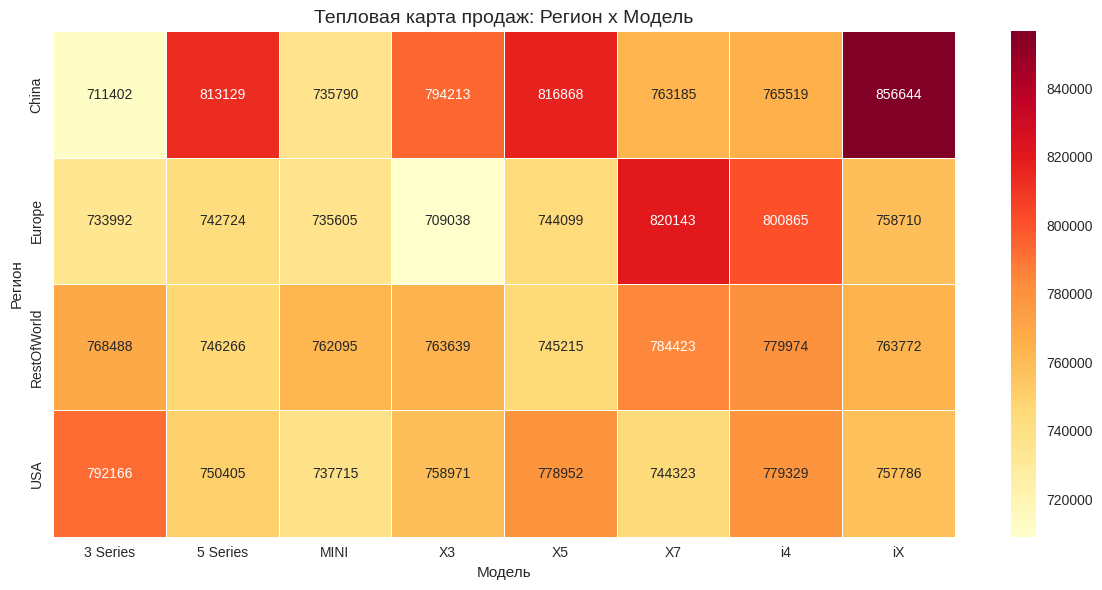

In [ ]:
# Тепловая карта: продажи по комбинации регион-модель
# Позволяет увидеть паттерны спроса в разрезе двух категориальных признаков

pivot_sales = df.pivot_table(values='Units_Sold', index='Region', columns='Model', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Тепловая карта продаж: Регион х Модель', fontsize=14)
plt.xlabel('Модель')
plt.ylabel('Регион')
plt.tight_layout()
plt.show()

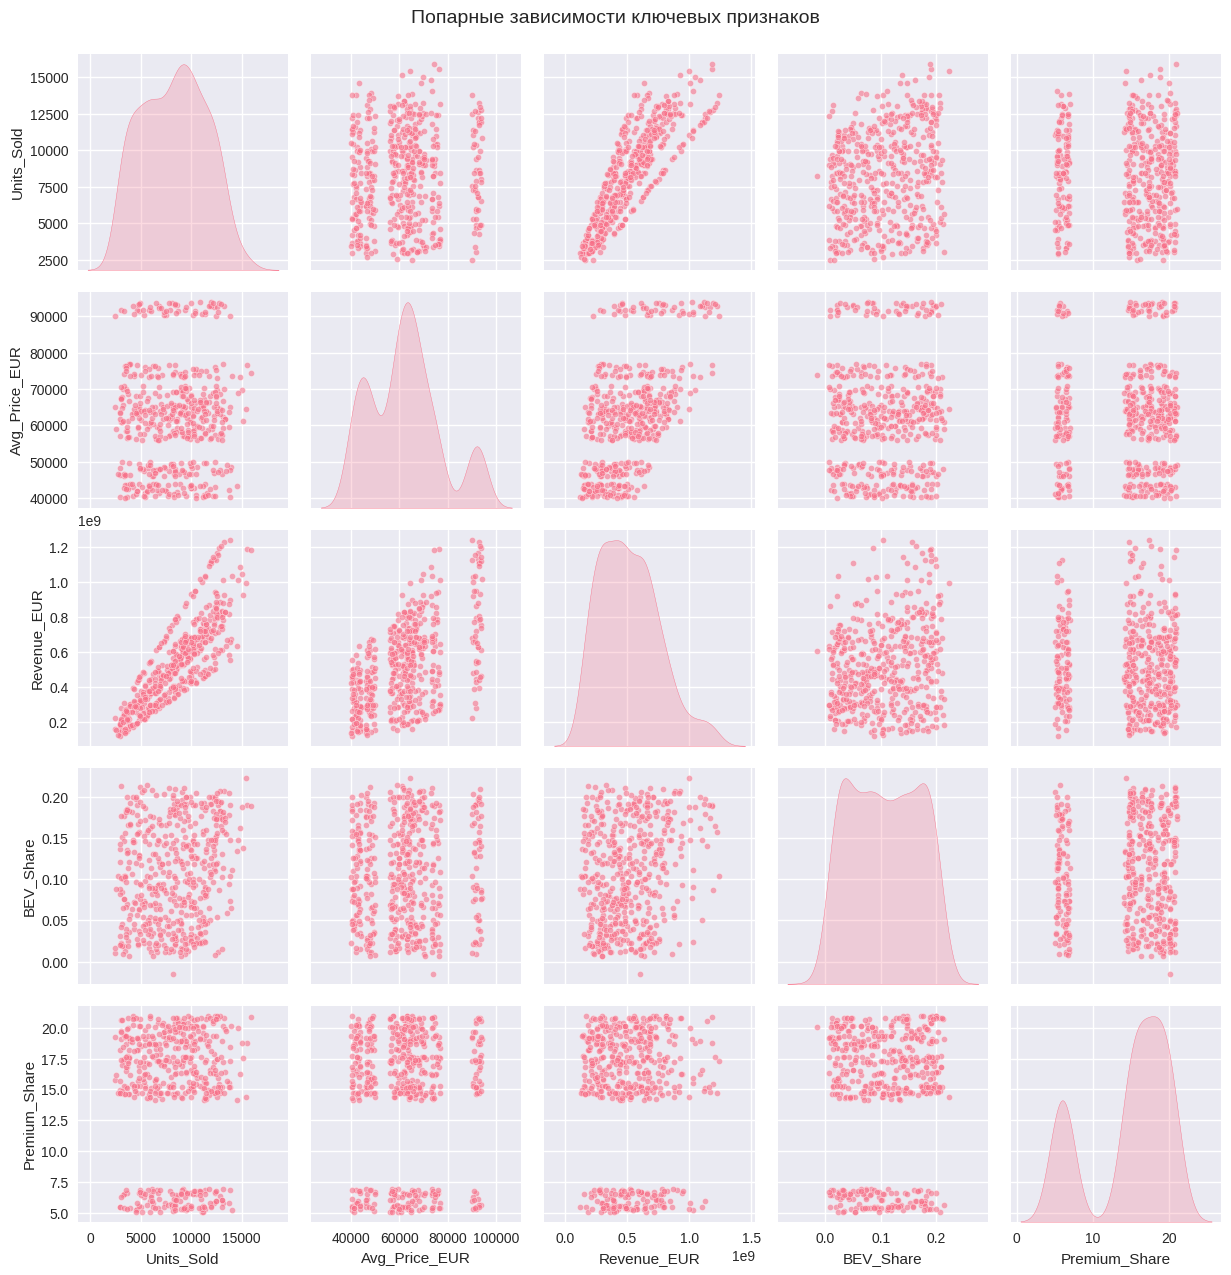

In [ ]:
# Pairplot: попарные зависимости ключевых числовых признаков
# Компактный способ исследовать взаимосвязи между несколькими переменными

# Выбираем числовые колонки для анализа
plot_cols = ['Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR', 'BEV_Share', 'Premium_Share']

# Используем сэмплирование для ускорения построения на больших данных
plot_data = df[plot_cols].sample(500, random_state=42)

sns.pairplot(plot_data, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Попарные зависимости ключевых признаков', y=1.02, fontsize=14)
plt.show()

## Раздел 4: Корреляционный анализ

Корреляционная матрица показывает коэффициенты корреляции Пирсона от -1 до 1. Маска скрывает дублирующую информацию (матрица симметрична), а аннотации с числами позволяют точно оценить силу связей. Мы программно извлекаем и сортируем значимые корреляции. Порог |r| > 0.5 выбран как общепринятый для обозначения умеренной и сильной связи. Этот блок демонстрирует, как извлекать бизнес-инсайты из данных. Мы агрегируем долю электромобилей по времени и строим тренд, затем вычисляем изменение между началом и концом периода для количественной оценки динамики.  

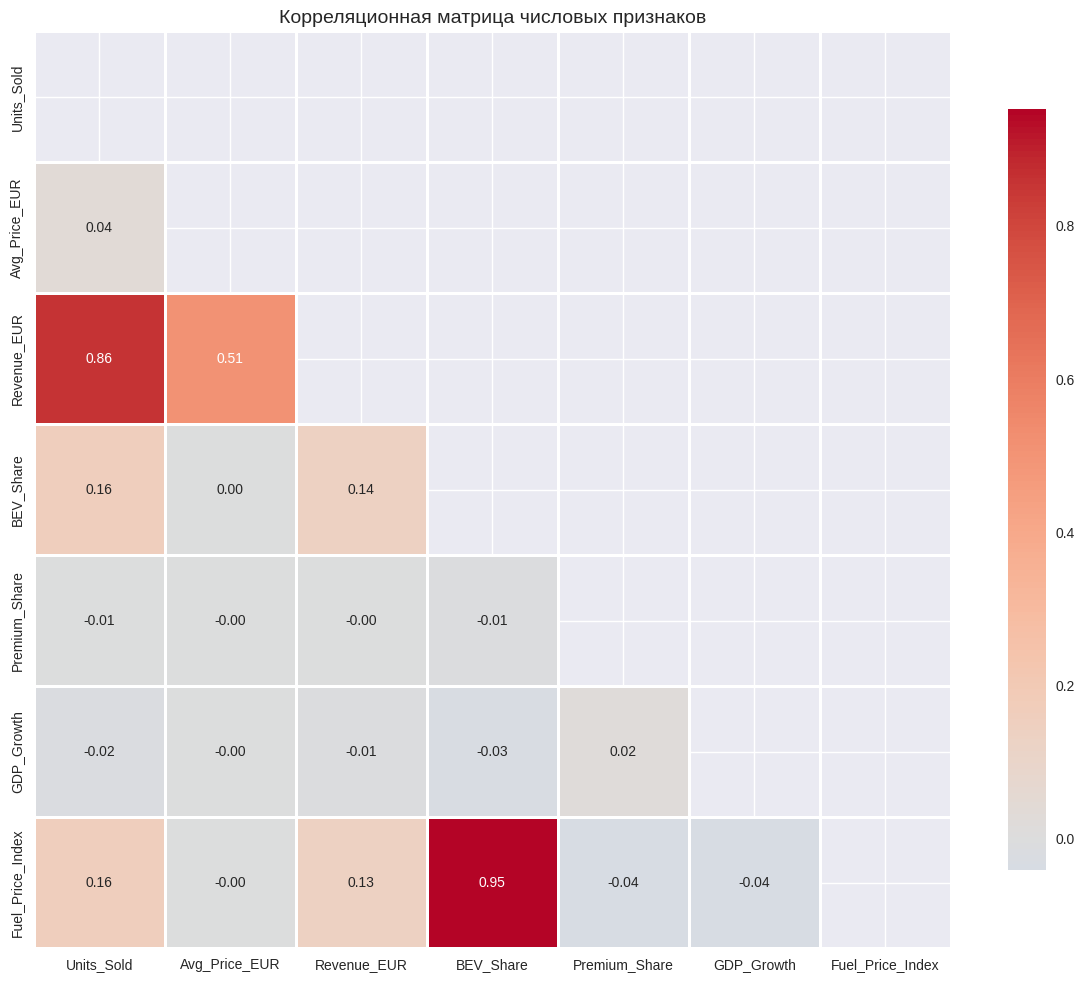

In [ ]:
# Вычисление и визуализация корреляционной матрицы
# Позволяет количественно оценить линейные связи между числовыми признаками

# Выбираем числовые колонки для расчёта корреляций
numeric_cols = ['Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR', 'BEV_Share',
                'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index']

# Вычисляем матрицу корреляций Пирсона
corr_matrix = df[numeric_cols].corr()

# Строим тепловую карту с маской для верхней треугольной части
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Вывод наиболее сильных корреляций в текстовом виде
# Автоматически фильтруем пары с |r| > 0.5 для фокусировки на значимых связях

print("Наиболее сильные корреляции (|r| > 0.5):")
strong_corr = []

# Проходим по верхней треугольной части матрицы
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            strong_corr.append((corr_matrix.index[i],
                              corr_matrix.columns[j],
                              corr_matrix.iloc[i, j]))

# Сортируем по абсолютному значению и выводим
for feat1, feat2, val in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"{feat1} <-> {feat2}: {val:+.3f}")

Наиболее сильные корреляции (|r| > 0.5):
Fuel_Price_Index <-> BEV_Share: +0.952
Revenue_EUR <-> Units_Sold: +0.856
Revenue_EUR <-> Avg_Price_EUR: +0.513


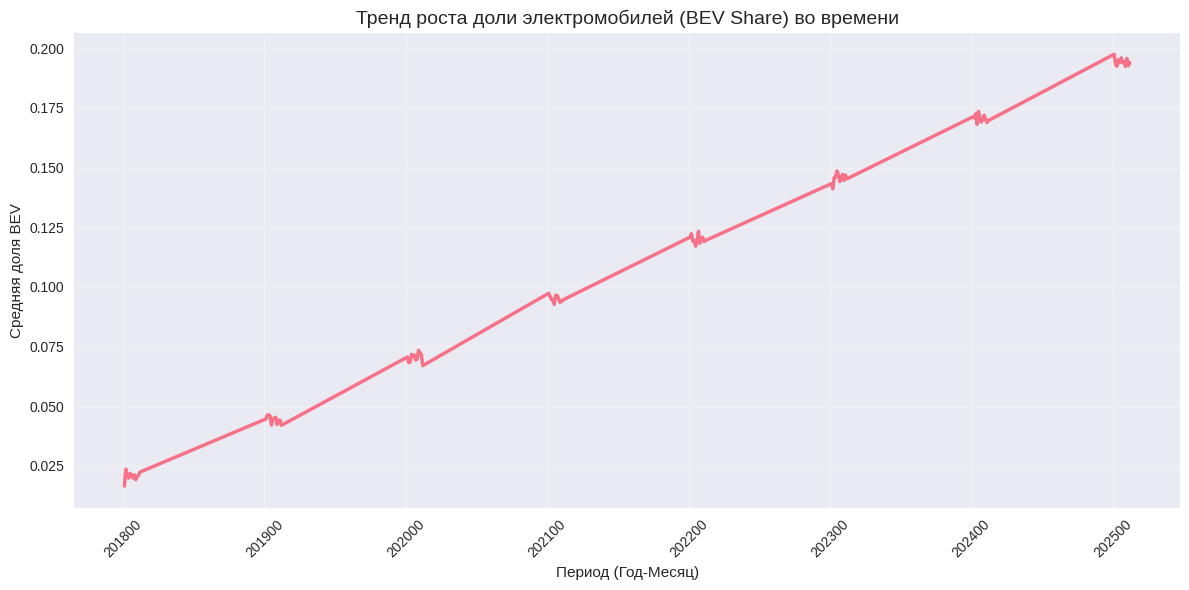

Рост доли электромобилей:
   Начало периода (2018): 2.07%
   Конец периода (2025): 19.43%


In [ ]:
# Дополнительный анализ: тренд роста доли электромобилей во времени
# Показывает динамику электрификации ассортимента как ключевой бизнес-метрики

# Создаём удобный формат периода для группировки
df['Year_Month'] = df['Year'] * 100 + df['Month']

# Вычисляем среднюю долю BEV по периодам
bev_trend = df.groupby('Year_Month')['BEV_Share'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=bev_trend, x='Year_Month', y='BEV_Share', linewidth=2.5)
plt.title('Тренд роста доли электромобилей (BEV Share) во времени', fontsize=14)
plt.xlabel('Период (Год-Месяц)')
plt.ylabel('Средняя доля BEV')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Выводим сравнение начала и конца периода
print("Рост доли электромобилей:")
start_val = df[df['Year']==2018]['BEV_Share'].mean() * 100
end_val = df[df['Year']==2025]['BEV_Share'].mean() * 100
print(f"   Начало периода (2018): {start_val:.2f}%")
print(f"   Конец периода (2025): {end_val:.2f}%")

In [ ]:

df.to_csv('bmw_sales_processed.csv', index=False)
print("Обработанные данные сохранены: bmw_sales_processed.csv")


Обработанные данные сохранены: bmw_sales_processed.csv
